In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


In [14]:
def Title_abstract_search(query, year_start, year_end, title=None, api_key=None):
    url = "https://api.openalex.org/works"

    params = {
        "filter": f"publication_year:{year_start}-{year_end}",
        "group_by": "publication_year",
        "per-page": 200,
        "search": query,
    }

    if api_key is not None:
        params["api_key"] = api_key

    r = requests.get(url, params=params)

    # Helpful debugging if OpenAlex rejects the query
    if not r.ok:
        print("URL:", r.url)
        print("Status:", r.status_code)
        print("Response:", r.text)
        r.raise_for_status()

    data = r.json()

    rows = [
        {
            "year": int(item["key"]),
            "count": item["count"]
        }
        for item in data.get("group_by", [])
    ]

    df = pd.DataFrame(rows)

    # Fill missing years with 0
    all_years = pd.DataFrame({"year": range(year_start, year_end + 1)})

    if df.empty:
        df = all_years.copy()
        df["count"] = 0
    else:
        df = (
            all_years
            .merge(df, on="year", how="left")
            .fillna({"count": 0})
        )
        df["count"] = df["count"].astype(int)

    if title is not None:
        df["query_title"] = title

    return df

In [ ]:
query = '"machine ethics" OR "machine morality" OR "AI ethics" OR "artificial intelligence ethics" OR "responsible AI"'
df = Title_abstract_search(
    query=query,
    year_start=1990,
    year_end=2026,
    title="Machine ethics / AI ethics",
    api_key="GNkJUcNqMpS9dXQIAaBXu7"
)

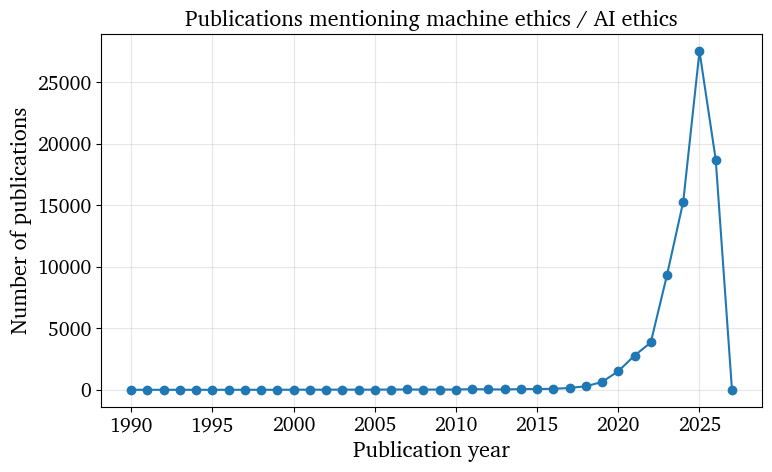

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(df["year"], df["count"], marker="o")
plt.xlabel("Publication year")
plt.ylabel("Number of publications")
plt.title("Publications mentioning machine ethics / AI ethics")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


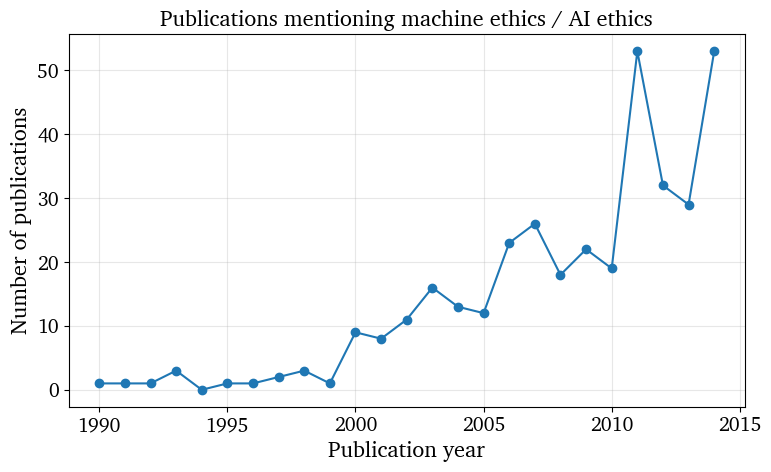

In [25]:
df = df[df["year"].isin(range(1990, 2015))]
plt.figure(figsize=(8, 5))
plt.plot(df["year"], df["count"], marker="o")
plt.xlabel("Publication year")
plt.ylabel("Number of publications")
plt.title("Publications mentioning machine ethics / AI ethics")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
query = '"machine ethics" OR "machine morality"'
df2 = Title_abstract_search(
    query=query,
    year_start=1990,
    year_end=2027,
    title="Machine ethics / AI ethics",
    api_key="GNkJUcNqMpS9dXQIAaBXu7"
)

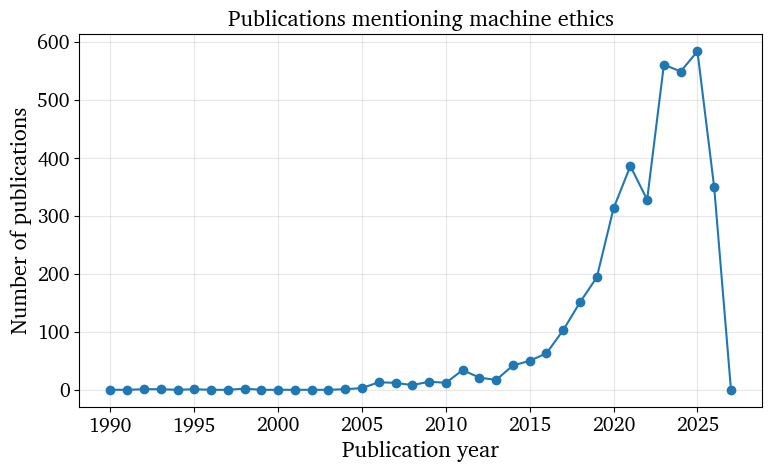

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(df2["year"], df2["count"], marker="o")
plt.xlabel("Publication year")
plt.ylabel("Number of publications")
plt.title("Publications mentioning machine ethics")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


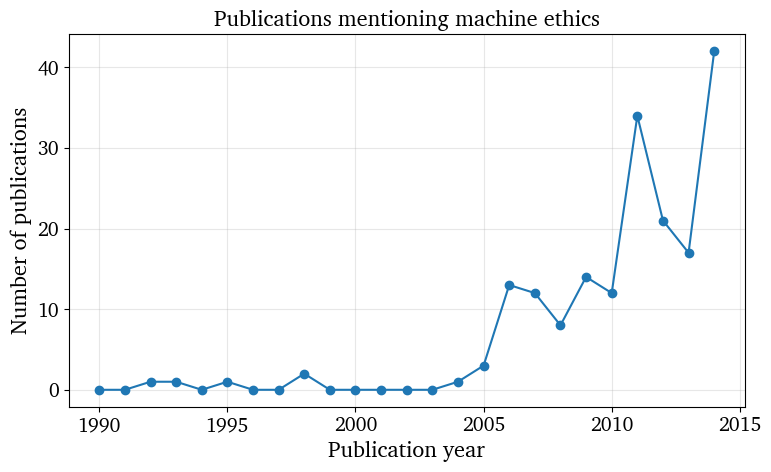

In [ ]:
df2 = df2[df2["year"].isin(range(1990, 2015))]
plt.figure(figsize=(8, 5))
plt.plot(df2["year"], df2["count"], marker="o")
plt.xlabel("Publication year")
plt.ylabel("Number of publications")
plt.title("Publications mentioning machine ethics")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
